# cNMF in `cellarium-ml`

Stephen Fleming

2026.04.08

The `cellarium-ml` project:
https://github.com/cellarium-ai/cellarium-ml

The specific implementation of cNMF we are actively working on:
https://github.com/cellarium-ai/cellarium-ml/pull/196

## What's in this notebook

Demo of how to run cNMF on a dataset.

## Installation of `cellarium-ml`

NOTE: You will need to use the `nmf_sf-amortized` branch of `cellarium-ml` on github

This can be accomplished by doing the following (here the example uses a conda environment to keep things separate):

```bash
(base) $ conda create -n cellarium python=3.10
(base) $ conda activate cellarium
(cellarium) $ pip install git+https://github.com/cellarium-ai/cellarium-ml.git@nmf_sf-amortized
```

Then ensure jupyter is pointing at your cellarium environment, either by installing jupyter inside the cellarium conda env, or by installing ipykernel there and pointing to that kernel from jupyter running in some other environment. If this is not clear, try

```bash
(cellarium) $ pip install jupyter
(cellarium) $ jupyter notebook
```

If the imports in the next section work, you are all set.

## Imports

In [1]:
import cellarium.ml.preprocessing
import cellarium.ml.data
import cellarium.ml.transforms
import cellarium.ml.api
import cellarium.ml.models

import lightning.pytorch as pl
import numpy as np
import pandas as pd
import torch

/Users/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
%load_ext autoreload
%autoreload 2

# Data

Specify a local h5ad file as your dataset.  Technically you can specify an http or gs filepath if you want, but training will be slower if it has to stream the file from somewhere that's not your machine.

NOTE: the only requirement is that all h5ad files must have the same `adata.var_names` if you have several h5ad files. (There are ways to relax this requirement but for now let's say it's required.)

Here I will demonstrate grabbing a file from a google bucket.

```bash
$ gsutil cp gs://broad-bican-cellarium-file-system/SMRI/glutamatergic_L5IT/L5IT_fold1.h5ad /dsde/working/sfleming/bican/
```

In [3]:
# specify any h5ad file data: can be multiple files in a list

h5ad_paths = [
    "/Users/sfleming/Documents/Projects/bican/cnmf/test_data/haley_bipolar_amygdala_OPCs_and_COPs.h5ad",
]

## Cellarium data setup

For this demo we are using the python API for cellarium.  This involves some boilerplate, so this is the boilerplate.

It's also possible to use command line versions of these tools.

In [4]:
h5ad_paths

['/Users/sfleming/Documents/Projects/bican/cnmf/test_data/haley_bipolar_amygdala_OPCs_and_COPs.h5ad']

(For remote files over the internet, this next cell can take a minute.)

In [5]:
# this sets up the data in a datamodule that cellarium needs

datamodule = cellarium.ml.CellariumAnnDataDataModule(
    dadc=cellarium.ml.data.DistributedAnnDataCollection(
        filenames=h5ad_paths,
        limits=np.cumsum(cellarium.ml.api.get_h5ad_files_n_cells(h5ad_paths))  # this looks up how many cells are in each file
    ),
    batch_keys={
        "x_ng": cellarium.ml.utilities.data.AnnDataField(
            attr="X", 
            convert_fn=cellarium.ml.utilities.data.densify,
        ),
        "var_names_g": cellarium.ml.utilities.data.AnnDataField(attr="var_names"),
        "obs_names_n": cellarium.ml.utilities.data.AnnDataField(attr="obs_names"),
    },
    batch_size=1024,
    shuffle=True,
    train_size=1.0,
)

datamodule.setup(stage="fit")

Reading n_obs from h5ad files: 100%|██████████| 1/1 [00:00<00:00, 7530.17file/s]


In [6]:
# check out what the dataset looks like

datamodule.dadc

DistributedAnnDataCollection object with n_obs × n_vars = 128203 × 32925
  constructed from 1 AnnData objects
    view of obs: 'donor', 'sex', 'age', 'diagnosis', 'predClass'

# Highly variable genes

The first step in cNMF is to choose which genes are involved in the computation.  If you already know this, you can skip this section.

If you want to use `cellarium-ml` to compute highly variable genes (like for a 100M cell dataset), this is how.

In [7]:
# get gene names to use later (and assume all files have the same genes)

var_names_g = datamodule.dadc.schema.attr_values["var"].index.to_numpy()
var_names_g[:5]

array(['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1'], dtype=object)

## Run `seurat_v3` flavor of highly variable gene selection

You have the option to use a `batch_key` as well, as in scanpy. Here we will not use a `batch_key`.

In [8]:
# set up the model that will be used to compute mean and var of each gene

n_top_genes = 2000
flavor = "seurat_v3"  # could also choose "seurat_v3_paper" but these are identical with no batch_key
output_path = "./cellarium_hvg.csv"  # an output file will be written here

hvg_module = cellarium.ml.CellariumModule(
    model=cellarium.ml.models.HVGSeuratV3(
        var_names_g=var_names_g,
        n_top_genes=n_top_genes,
        flavor=flavor,
        n_batch=1,
        use_batch_key=False,
        output_path=output_path,
    )
)

In [9]:
trainer = pl.Trainer(
    accelerator="cpu",
    devices=1,
    max_epochs=2,  # HVGSeuratV3 happens in two passes
    default_root_dir="tmp/hvg",
)
trainer.fit(hvg_module, datamodule)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 1      | train
-------------------------------------------------------
1         Trainable params
0         Non-trainable params
1         Total params
0.000     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode


Epoch 1: 100%|██████████| 126/126 [01:52<00:00,  1.12it/s, v_num=2]

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 1: 100%|██████████| 126/126 [01:52<00:00,  1.12it/s, v_num=2]


In [10]:
# the model writes an output csv with the highly variable genes

hvg_df = pd.read_csv(output_path.replace(".csv", "__hvg_only.csv"), index_col=0)
hvg_df

,highly_variable_rank,variances_norm,highly_variable
gene,,,
FRMD4A,0.0,35.114753,True
AC011287.1,1.0,19.797082,True
HSPH1,2.0,18.799163,True
ST18,3.0,12.281309,True
RASGEF1B,4.0,11.566115,True
...,...,...,...
RNF217,1995.0,1.146049,True
CACNA1E,1996.0,1.145943,True
AL591885.1,1997.0,1.145710,True


In [11]:
# the highly variable genes

hvg_var_names_g = hvg_df.index.to_numpy()
hvg_var_names_g

array(['FRMD4A', 'AC011287.1', 'HSPH1', ..., 'AL591885.1', 'CNIH3',
       'GSTCD'], dtype=object)

You could also use your own pre-computed list of highly variable genes.  Just set `hvg_var_names_g` equal to your own numpy array here.

## Compute per-gene std of raw values

Per-gene raw count standard deviations are used as a preprocessing transformation in cNMF.

In `cellarium-ml`, this computation is separate from highly-variable gene computation.

In [12]:
len(hvg_var_names_g)

2000

In [13]:
len(var_names_g)

32925

In [14]:
# set up the model that will be used to compute mean and var of each gene

raw_onepass_module = cellarium.ml.CellariumModule(
    model=cellarium.ml.models.OnePassMeanVarStd(
        var_names_g=var_names_g,
    )
)

In [15]:
trainer = pl.Trainer(
    accelerator="cpu",
    devices=1,
    max_epochs=1,
    default_root_dir="tmp/onepass",
)
trainer.fit(raw_onepass_module, datamodule)

std = pd.Series(raw_onepass_module.model.std_g + 1e-5, index=var_names_g)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 1      | train
-------------------------------------------------------
1         Trainable params
0         Non-trainable params
1         Total params
0.000     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 126/126 [01:11<00:00,  1.76it/s, v_num=30]

`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 126/126 [01:11<00:00,  1.76it/s, v_num=30]


In [16]:
std

A1BG              0.035205
A1BG-AS1          0.046025
A1CF              0.062942
A2M               0.369948
A2M-AS1           0.192276
                    ...   
ZZEF1             0.861115
ZZZ3              2.046591
hsa-mir-548d-2    0.008841
snoR1             0.054872
snoZ196           0.010459
Length: 32925, dtype: float32

# cNMF

## Run NMF

Set things up to run cNMF in cellarium.

In [17]:
# user's choice for the number of components: must input a python list

# k_values = [18]
k_values = list(range(3, 6))

In [18]:
# user's choice for the number of NMF replicates that should go into consensus

nmf_replicates = 50

In [22]:
# get set up for training

nmf_model = cellarium.ml.models.OnlineNonNegativeMatrixFactorization(
    var_names_g=hvg_var_names_g,
    k_values=k_values,
    r=nmf_replicates,
    algorithm="nmf_torch_hals",  # this is the algorithm that best reproduced the McCarroll results
    n_cells_total=len(datamodule.dadc),
)

nmf_module = cellarium.ml.CellariumModule(
    cpu_transforms=[
        cellarium.ml.transforms.Filter(filter_list=hvg_var_names_g, ordering=True),
    ],
    transforms=[
        cellarium.ml.transforms.DivideByScale(
            scale_g=torch.tensor(std.values, device="mps"),
            var_names_g=std.index.to_numpy(),
            eps=1e-4,
        ),
    ],
    model=nmf_model,
)

datamodule.setup(stage="fit")

trainer_nmf = pl.Trainer(
    accelerator="auto",
    devices=1,
    max_epochs=10,  # this is up for debate, but empirically 10 seems to be enough
    default_root_dir="tmp/nmf",
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [23]:
# specifically to suppress compilation problems on methods01 server
# some kind of gcc problem on that server
# feel free to delete this code cell if you want, but it won't hurt
# it also doesn't look like errors are actually being suppressed

import torch._dynamo
torch._dynamo.config.suppress_errors = True

In [24]:
# train on the data

import time

pl.seed_everything(0)  # not required but helps make this notebook reproducible

t = time.time()

trainer_nmf.fit(nmf_module, datamodule)

print(f"Full run took {(time.time() - t) / 60:.2f} mins")

Seed set to 0

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 1      | train
-------------------------------------------------------
1         Trainable params
0         Non-trainable params
1         Total params
0.000     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


Epoch 0:   0%|          | 0/126 [00:00<?, ?it/s]  

W0415 12:16:58.247000 36202 site-packages/torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch 0:   2%|▏         | 2/126 [00:43<44:44,  0.05it/s, v_num=41]  

W0415 12:17:39.857000 36202 site-packages/torch/_dynamo/convert_frame.py:1743] [0/8] torch._dynamo hit config.recompile_limit (8)
W0415 12:17:39.857000 36202 site-packages/torch/_dynamo/convert_frame.py:1743] [0/8]    function: 'inner' (/Users/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/torch/_dynamo/external_utils.py:67)
W0415 12:17:39.857000 36202 site-packages/torch/_dynamo/convert_frame.py:1743] [0/8]    last reason: 0/6: GLOBAL_STATE changed: grad_mode 
W0415 12:17:39.857000 36202 site-packages/torch/_dynamo/convert_frame.py:1743] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0415 12:17:39.857000 36202 site-packages/torch/_dynamo/convert_frame.py:1743] [0/8] To diagnose recompilation issues, see https://docs.pytorch.org/docs/main/user_guide/torch_compiler/compile/programming_model.recompilation.html


Epoch 9: 100%|██████████| 126/126 [01:54<00:00,  1.10it/s, v_num=41]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 126/126 [01:54<00:00,  1.10it/s, v_num=41]
Full run took 21.85 mins


In [25]:
# see the shape of the NMF gene programs that have been inferred: [replicates, k, genes]

for k in nmf_model.k_values:
    print(getattr(nmf_model, f"D_{k}_rkg").shape)

torch.Size([50, 3, 2000])
torch.Size([50, 4, 2000])
torch.Size([50, 5, 2000])


In [35]:
k_values2 = list(range(6, 11))

# get set up for training

nmf_model2 = cellarium.ml.models.OnlineNonNegativeMatrixFactorization(
    var_names_g=hvg_var_names_g,
    k_values=k_values2,
    r=nmf_replicates,
    algorithm="nmf_torch_hals",  # this is the algorithm that best reproduced the McCarroll results
    n_cells_total=len(datamodule.dadc),
)

nmf_module2 = cellarium.ml.CellariumModule(
    cpu_transforms=[
        cellarium.ml.transforms.Filter(filter_list=hvg_var_names_g, ordering=True),
    ],
    transforms=[
        cellarium.ml.transforms.DivideByScale(
            scale_g=torch.tensor(std.values),
            var_names_g=std.index.to_numpy(),
            eps=1e-4,
        ),
    ],
    model=nmf_model2,
)

datamodule.setup(stage="fit")

trainer_nmf2 = pl.Trainer(
    accelerator="auto",
    devices=1,
    max_epochs=10,  # this is up for debate, but empirically 10 seems to be enough
    default_root_dir="tmp/nmf3",
)

# train on the data

import time

pl.seed_everything(0)  # not required but helps make this notebook reproducible

t = time.time()

trainer_nmf2.fit(nmf_module2, datamodule)

print(f"Full run took {(time.time() - t) / 60:.2f} mins")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Seed set to 0


KeyError: 'model'

## Set up to explore outputs

We have a helper class that facilitates downstream analysis steps. Here we instantiate it and use it to get various outputs.

In [26]:
from cellarium.ml.models.nmf import NMFOutput

nmf_output = NMFOutput(
    nmf_module=nmf_module,
    datamodule=datamodule,
)

In [27]:
nmf_output

NMFOutput(
    nmf_module=CellariumModule(
         [ dataloader CPU transforms = 
           CellariumPipeline(
             (0): Filter(filter_list=['FRMD4A' 'AC011287.1' 'HSPH1' ... 'AL591885.1' 'CNIH3' 'GSTCD'], ordering=True, allow_missing=False)
           )
         ]
         transforms = CellariumPipeline(
           (0): DivideByScale(scale_g=tensor([0.0352, 0.0460, 0.0629,  ..., 0.0088, 0.0549, 0.0105]), var_names_g=['A1BG' 'A1BG-AS1' 'A1CF' ... 'hsa-mir-548d-2' 'snoR1' 'snoZ196'], eps=0.0001)
         )
         model = OnlineNonNegativeMatrixFactorization(
          (transform__filter_to_hvgs): Filter(filter_list=['FRMD4A' 'AC011287.1' 'HSPH1' ... 'AL591885.1' 'CNIH3' 'GSTCD'], ordering=True, allow_missing=False)
        )
        ),
    datamodule={Train dataloader: size=126}
        {Validation dataloader: size=0}
        {Test dataloader: None}
        {Predict dataloader: size=126}
)
with consensus []

In [28]:
nmf_module.setup(stage='predict')

## Create k-selection plot

This is what Kotliar cNMF would produce with default values for `local_neighborhood_size=0.3` and `density_threshold=0.5`

cellarium.ml.models.nmf - INFO - Computing consensus factors with default hyperparameters...
cellarium.ml.models.nmf - INFO - Calculating reconstruction error (requires an entire pass through the data)...


100%|██████████| 126/126 [01:33<00:00,  1.35it/s]


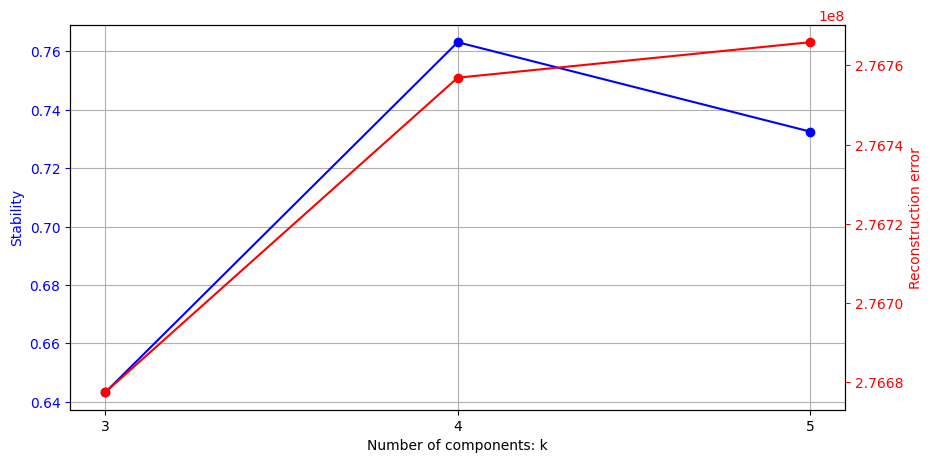

In [29]:
nmf_output.default_k_selection_plot()

This is a new version of this plot which I've invented... it tries to maximize stability for each `k` by separately choosing `density_threshold` values that maximize stability for that `k`. This plot, in my opinion, better reflects which `k` you should choose, because after you choose `k` you're going to optimize your `density_threshold` choice. But I've found that these almost always look pretty similar, and the maximal-stability version takes longer to compute.

cellarium.ml.models.nmf - INFO - Computing consensus factors, searching for best density thresholds...


  4%|████▌                                                                                                                            | 1/28 [00:02<00:57,  2.13s/it]

cellarium.ml.models.nmf - WARNING - Unable to find local minima in k=4 density histogram... 'fast' mode will fall back to 'exhaustive'


 79%|████████████████████████████████████████████████████████████████████████████████████████████████████▌                           | 22/28 [03:46<01:14, 12.35s/it]

cellarium.ml.models.nmf - WARNING - Unable to find local minima in k=25 density histogram... 'fast' mode will fall back to 'exhaustive'


...

 96%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍    | 27/28 [11:47<01:14, 74.75s/it]

cellarium.ml.models.nmf - WARNING - Unable to find local minima in k=30 density histogram... 'fast' mode will fall back to 'exhaustive'


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [14:26<00:00, 30.95s/it]

cellarium.ml.models.nmf - INFO - Computing reconstruction errors...



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [01:35<00:00,  5.95s/it]


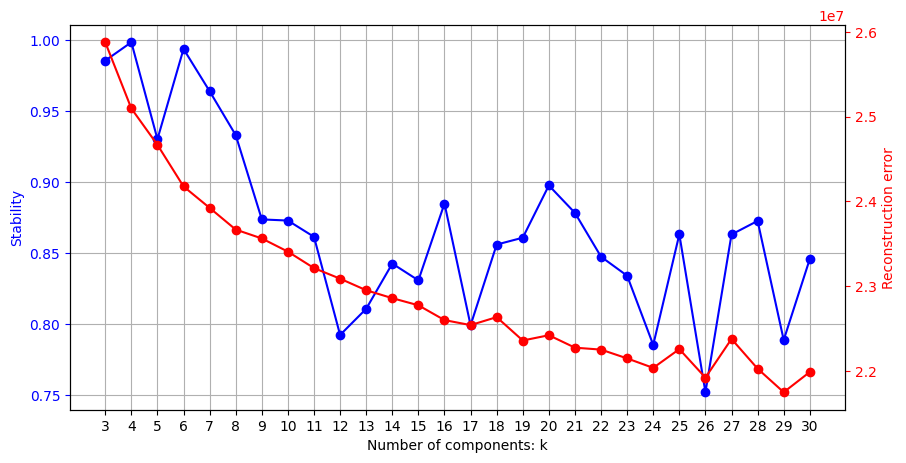

In [57]:
nmf_output.maximal_stability_k_selection_plot()

Here is where you manually choose the best `k` value:

In [87]:
best_k = 20

In [88]:
# you can look up the "best" density_threshold value this way if you ran the maximal-stability thing above

nmf_output.consensus[best_k]['density_threshold']

0.14500001

In [73]:
# %%time

# # this is how you manually compute consensus factors with specific parameter values

# nmf_output.compute_consensus_factors(k_values=[18], density_threshold=0.145, local_neighborhood_size=0.3)

Here is where you create a clustermap plot and the histogram of neighbor distances.

If you choose `density_threshold=None` this will use whatever value has been computed last for the `compute_consensus_factors()` calculation for that `k`. (This runs automatically under the hood when you create the k-selection plots above.)

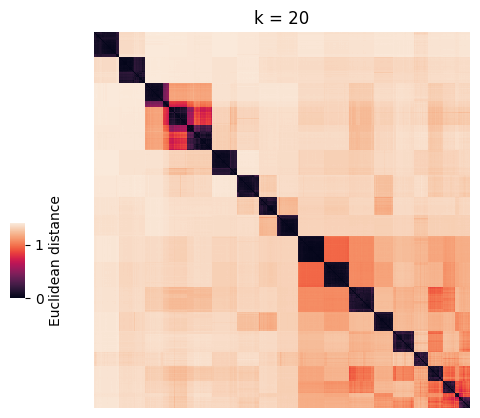

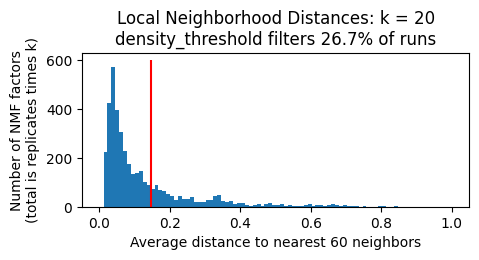

In [89]:
nmf_output.plot_clustermap(k=best_k, density_threshold=None)
# None will use whatever value ran last. Some other value will re-compute consensus give that threshold.

## Compute per-cell loadings

In [90]:
best_k

20

The loadings of each factor, computed for each cell.

In [91]:
# get per-cell factor loadings using the best k: this takes time
# `normalize` controls whether the per-cell loadings sum to 1

df = nmf_output.compute_loadings(k=best_k, normalize=False)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:07<00:00,  2.20it/s]


In [92]:
df.shape

(16120, 20)

In [93]:
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
SMRI_V10_rxn2_TTCACGCTCGACCAAT,10.127955,117.478386,0.000000,0.000000,9.309329,0.048388,14.163288,55.110863,0.000000,0.000000,5.205122,1.758941,0.000000,0.000000,37.900719,269.089417,68.682411,0.000000,0.000000,13.287407
SMRI_V10_rxn8_TGATGGTTCAATGTCG,3.910911,9.151962,14.520025,0.740264,0.000000,8.511385,0.000000,284.439758,10.484999,0.000000,0.000000,0.000000,11.366361,1.402890,4.020638,4.730913,69.906288,0.000000,0.414071,0.000000
SMRI_V1_rxn5_CTACATTGTGCATTAC,0.000000,0.000000,133.231918,0.000000,0.000000,8.040569,2.218618,70.647614,15.192509,100.135056,0.000000,5.244637,45.902565,0.000000,60.580387,449.290253,25.678257,46.796783,67.831161,10.364137
SMRI_V9_rxn5_TTTATGCGTAGGTCAG,0.391588,0.000000,1.854358,5.456553,27.026649,13.051805,33.143936,0.000000,0.000000,88.538452,0.000000,2.884748,395.734344,36.979324,24.037285,55.418507,103.233513,161.239746,407.801300,0.000000
SMRI_V7_cryo_rxn3_TCGATTTTCTCGACCT,0.000000,86.877197,0.000000,0.706173,13.053868,0.000000,0.000000,4.149422,0.000000,0.000000,26.013319,0.000000,69.044518,0.000000,31.575500,20.963148,51.224632,2.509980,0.000000,11.288630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SMRI_V3_rxn3_TAATCTCCAAAGCACG,1.529747,197.719650,48.265896,2.441951,0.793379,17.745754,32.181328,8.388980,5.050056,105.690323,0.000000,0.000000,0.000000,22.965437,0.000000,457.216431,29.731279,0.000000,0.000000,0.000000
SMRI_V9_rxn4_AATGGCTGTGACCGTC,0.000000,14.036383,9.698905,0.000000,24.279922,0.000000,17.346659,0.000000,0.000000,7.204304,33.269253,0.000000,234.336838,10.871179,74.604477,19.402590,71.593704,267.534027,52.221996,0.000000
SMRI_V8_rxn3_TTCCTAACACCGCTAG,0.000000,162.142853,453.477600,18.748552,362.258240,74.556007,52.907326,0.000000,0.000000,191.079819,138.004761,13.858334,843.549133,146.531235,0.000000,83.001274,963.459717,0.000000,189.262161,0.000000
SMRI_V6_rxn4_CAAGAGGCAGAGGTAC,3.162091,0.000000,80.033051,5.005225,0.000000,10.326350,0.000000,15.041742,12.295222,51.237278,32.156681,0.000000,162.226013,14.562302,0.000000,65.755379,152.214340,530.945435,44.379944,79.429161


### Save cell loadings

In [94]:
# cell_loading_file = "your_cell_loadings_filename_here.txt"
# df.to_csv(cell_loading_file, header=True, index=True, sep='\t')
# cell_loading_file

## Access consensus gene programs

In [95]:
# the consensus gene programs are found here

nmf_output.consensus[best_k]['consensus_D_kg'].shape

torch.Size([20, 2000])

In [97]:
# make this into a labeled dataframe

df_gene = pd.DataFrame(data=nmf_output.consensus[best_k]['consensus_D_kg'].t().numpy(), index=hvg_var_names_g)
df_gene

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
LINC01090,0.000000,0.000000,0.000000,0.000000,0.000000,0.001076,0.000272,0.000000,0.000045,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000042,0.003398,0.000000
LINC01194,0.000000,0.000142,0.000334,0.000000,0.000017,0.000194,0.000000,0.000000,0.000000,0.000224,0.000000,0.000000,0.000040,0.000015,0.000000,0.000259,0.000000,0.000000,0.000000,0.000000
CARTPT,0.000000,0.000000,0.000000,0.000000,0.000000,0.002404,0.001975,0.000000,0.000000,0.000000,0.000000,0.001154,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
LINC02306,0.000000,0.000000,0.000000,0.000000,0.000000,0.000501,0.002340,0.000000,0.000000,0.000000,0.000000,0.005148,0.000000,0.001116,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ST18,0.009803,0.000000,0.000000,0.000000,0.000000,0.000000,0.000067,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DDR2,0.000746,0.000229,0.000478,0.000338,0.000262,0.000496,0.000000,0.000288,0.002970,0.000000,0.000178,0.000000,0.000485,0.000198,0.001387,0.000422,0.000023,0.000115,0.000265,0.000325
AC008050.1,0.000341,0.000954,0.000000,0.001361,0.000593,0.000000,0.000351,0.000638,0.000616,0.000138,0.000000,0.000000,0.000403,0.000197,0.002521,0.000857,0.000000,0.000368,0.000603,0.000000
AC009262.1,0.000075,0.000816,0.000000,0.000000,0.000000,0.000000,0.000764,0.000284,0.000000,0.000000,0.000556,0.000000,0.001084,0.001296,0.000531,0.000121,0.000000,0.001051,0.000268,0.000134
AC044849.2,0.000000,0.000045,0.000000,0.000000,0.000015,0.003782,0.000352,0.000209,0.000449,0.000168,0.000000,0.000000,0.000237,0.000117,0.000115,0.000165,0.000221,0.000056,0.000000,0.000000


### Save gene programs

In [98]:
# gene_programs_file = "your_consensus_gene_program_filename_here.txt"
# df_gene.to_csv(gene_programs_file, header=True, index=True, sep='\t')

Here was my old check to see if one of these programs overlapped strongly with the McCarroll special program.

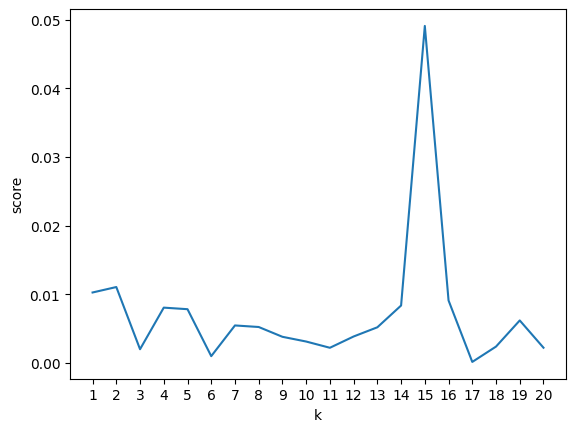

15

In [101]:
import matplotlib.pyplot as plt

vals = df_gene.loc[
    ['DCDC1', 'PRKCH', 'RFC3', 'ZBTB20', 'GPC5', 'PPARG', 'DGKG', 
     # 'FHIT', 
     'NEAT1', 'SYN3', 
     # 'CDHR3', 'SPAG16', 
     'LINC01483', 'LINC01481']
].sum(axis=0)
vals.plot()
plt.xticks(range(best_k), labels=range(1, best_k + 1))
plt.xlabel('k')
plt.ylabel('score')
plt.show()

probable_program = vals.idxmax()
probable_program + 1